# ДЗ 1 — ReAct-агент на LangGraph
**Моісеєнко Світлана** · курс «Проєктування автономних агентів» (теми 1–2, 4)

## Мета
Побудувати повноцінного **ReAct-агента** (Reasoning + Acting) на LangGraph: цикл `LLM → tools → LLM`,
інструменти з Pydantic v2 валідацією, structured outputs, захисні механізми та логування траєкторії.

## Структура ноутбука
| Секція | Зміст |
|---|---|
| 0 | Встановлення залежностей |
| 1 | Імпорти та конфігурація |
| 2 | Інструменти (4 шт.) з Pydantic v2 схемами та `field_validator` |
| 3 | LLM-провайдер (OpenAI GPT-4.1 + детермінований офлайн-фолбек) |
| 4 | LangGraph: стан, вузли `agent`/`tools`/`finalize`, conditional edges |
| 5 | Запуск, логування траєкторії у `trajectory.json`, демонстрація guardrails |
| 6 | 5 тест-кейсів → `test_results.json` |
| 7 | Візуалізація результатів |
| 8 | Висновки та аналіз |

## Архітектура агента
```
           ┌──────────────────────────────────────────┐
           ▼                                          │
START → [agent] ──tool_calls?──yes──→ [tools] ────no-halt
           │                             │
           └──no / halted──→ [finalize] ←─halted
                                 │
                                 ▼
                                END
```

## Секція 0. Встановлення залежностей
Клітинка ідемпотентна: у Colab доставляє відсутні пакети, локально — нічого не робить.

In [1]:
import importlib.util
import subprocess
import sys

REQUIRED_PACKAGES = {
    "langgraph": "langgraph",
    "langchain_core": "langchain-core",
    "langchain_openai": "langchain-openai",
    "pydantic": "pydantic>=2",
    "matplotlib": "matplotlib",
}

missing = [pkg for module, pkg in REQUIRED_PACKAGES.items() if importlib.util.find_spec(module) is None]
if missing:
    print(f"Встановлюю: {', '.join(missing)}")
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", *missing], check=True)
print("Усі залежності доступні")

Усі залежності доступні


## Секція 1. Імпорти та конфігурація
`AgentConfig` — єдине джерело правди для захисних механізмів (`max_steps`, `timeout_s`, детекція зациклення).

In [2]:
import ast
import json
import operator
import os
import re
import time
from collections import Counter
from pathlib import Path
from typing import Annotated, Any, Literal, TypedDict

from langchain_core.language_models.chat_models import BaseChatModel
from langchain_core.messages import AIMessage, AnyMessage, HumanMessage, SystemMessage, ToolMessage
from langchain_core.outputs import ChatGeneration, ChatResult
from langchain_core.tools import BaseTool, tool
from langchain_core.utils.function_calling import convert_to_openai_tool
from langgraph.graph import END, START, StateGraph
from langgraph.graph.message import add_messages
from pydantic import BaseModel, Field, field_validator

OUTPUT_DIR = Path.cwd()
TRAJECTORY_PATH = OUTPUT_DIR / "trajectory.json"
TEST_RESULTS_PATH = OUTPUT_DIR / "test_results.json"


class AgentConfig(BaseModel):
    """Налаштування агента та його захисних механізмів."""

    max_steps: int = Field(default=8, ge=1, le=50, description="Максимум ітерацій циклу LLM→tools")
    timeout_s: float = Field(default=60.0, gt=0, description="Загальний тайм-аут виконання, секунд")
    detect_loops: bool = Field(default=True, description="Зупиняти при повторному ідентичному tool call")
    model_name: str = Field(default="gpt-4.1", description="Назва моделі провайдера")
    temperature: float = Field(default=0.0, ge=0.0, le=2.0)


DEFAULT_CONFIG = AgentConfig()

SYSTEM_PROMPT = """Ти — ReAct-агент. Працюй за циклом:
Thought: коротко поміркуй, яких даних тобі бракує.
Action: виклич потрібний інструмент (одразу кілька, якщо вони незалежні).
Observation: проаналізуй результат інструмента.
Повторюй, доки не зможеш дати повну відповідь.

Правила:
- Не вигадуй числа й факти — бери їх лише з результатів інструментів.
- Не викликай той самий інструмент з тими самими аргументами двічі.
- Якщо інструмент повернув ERROR — прочитай текст помилки та виправ аргументи.
- Коли даних достатньо, дай фінальну відповідь українською мовою."""


def save_json(payload: Any, path: Path) -> None:
    """Зберігає структуру у JSON-файл з підтримкою кирилиці."""
    path.write_text(json.dumps(payload, ensure_ascii=False, indent=2), encoding="utf-8")
    print(f"Збережено: {path.name} ({path.stat().st_size / 1024:.1f} КБ)")


def fmt_duration(seconds: float) -> str:
    """Форматує тривалість: мілісекунди для швидких запусків, секунди — для повільних."""
    return f"{seconds * 1000:.1f} мс" if seconds < 1 else f"{seconds:.2f} с"


print(f"Python {sys.version.split()[0]}")
print(f"Конфігурація: max_steps={DEFAULT_CONFIG.max_steps}, timeout={DEFAULT_CONFIG.timeout_s:.0f} с, "
      f"детекція зациклення={DEFAULT_CONFIG.detect_loops}")

Python 3.11.8
Конфігурація: max_steps=8, timeout=60 с, детекція зациклення=True


## Секція 2. Інструменти з Pydantic v2 схемами

Кожен інструмент має: `BaseModel` для параметрів, `Field(description=...)` (LLM бачить ці описи),
`field_validator` для перевірки вхідних даних та docstring українською.

| Інструмент | Призначення | Валідація |
|---|---|---|
| `calculator` | арифметичні обчислення | лише цифри й оператори, довжина ≤ 200, безпечний AST |
| `convert_currency` | конвертація валют | сума > 0, код валюти — 3 літери зі списку |
| `get_weather` | погода по місту | місто нормалізується й перевіряється по довіднику |
| `analyze_text` | статистика тексту | непорожній текст ≤ 5000 символів, `top_n` 1–10 |

In [3]:
USD_RATES = {"USD": 1.0, "EUR": 0.92, "UAH": 41.50, "PLN": 3.98, "GBP": 0.79}

WEATHER_DB = {
    "Київ": {"temp_c": 18.5, "description": "мінлива хмарність", "humidity_percent": 62},
    "Львів": {"temp_c": 15.0, "description": "дощ", "humidity_percent": 81},
    "Одеса": {"temp_c": 24.0, "description": "ясно", "humidity_percent": 55},
    "Харків": {"temp_c": 20.0, "description": "хмарно", "humidity_percent": 68},
}

_ALLOWED_EXPR = re.compile(r"^[0-9+\-*/().,%\s]+$")
_SAFE_AST_NODES = (
    ast.Expression, ast.BinOp, ast.UnaryOp, ast.Constant,
    ast.Add, ast.Sub, ast.Mult, ast.Div, ast.FloorDiv, ast.Mod, ast.Pow, ast.USub, ast.UAdd,
)


def _as_json(payload: dict) -> str:
    """Уніфікований формат результату інструмента для LLM."""
    return json.dumps(payload, ensure_ascii=False)


class CalculatorArgs(BaseModel):
    """Параметри інструмента calculator."""

    expression: str = Field(description="Арифметичний вираз, напр. '2400*0.15+300'")

    @field_validator("expression")
    @classmethod
    def validate_expression(cls, value: str) -> str:
        value = value.strip()
        if not value:
            raise ValueError("Вираз не може бути порожнім")
        if len(value) > 200:
            raise ValueError("Вираз надто довгий (максимум 200 символів)")
        if not _ALLOWED_EXPR.match(value):
            raise ValueError("Дозволені лише цифри, дужки та оператори + - * / % ** //")
        return value


class ConvertCurrencyArgs(BaseModel):
    """Параметри інструмента convert_currency."""

    amount: float = Field(description="Сума для конвертації, більша за 0")
    from_currency: str = Field(description=f"Код валюти-джерела: {', '.join(USD_RATES)}")
    to_currency: str = Field(description=f"Код цільової валюти: {', '.join(USD_RATES)}")

    @field_validator("amount")
    @classmethod
    def validate_amount(cls, value: float) -> float:
        if value <= 0:
            raise ValueError("Сума мусить бути більшою за 0")
        if value > 1_000_000_000:
            raise ValueError("Сума завелика (максимум 1e9)")
        return round(value, 2)

    @field_validator("from_currency", "to_currency")
    @classmethod
    def validate_currency(cls, value: str) -> str:
        code = value.strip().upper()
        if code not in USD_RATES:
            raise ValueError(f"Невідома валюта '{value}'. Доступні: {', '.join(USD_RATES)}")
        return code


class WeatherArgs(BaseModel):
    """Параметри інструмента get_weather."""

    city: str = Field(description=f"Назва міста українською: {', '.join(WEATHER_DB)}")

    @field_validator("city")
    @classmethod
    def validate_city(cls, value: str) -> str:
        city = value.strip().capitalize()
        if city not in WEATHER_DB:
            raise ValueError(f"Немає даних для міста '{value}'. Доступні: {', '.join(WEATHER_DB)}")
        return city


class TextStatsArgs(BaseModel):
    """Параметри інструмента analyze_text."""

    text: str = Field(description="Текст для аналізу")
    top_n: int = Field(default=3, ge=1, le=10, description="Скільки найчастіших слів повернути")

    @field_validator("text")
    @classmethod
    def validate_text(cls, value: str) -> str:
        text = value.strip()
        if len(text) < 10:
            raise ValueError("Текст замалий для аналізу (мінімум 10 символів)")
        if len(text) > 5000:
            raise ValueError("Текст завеликий (максимум 5000 символів)")
        return text


@tool("calculator", args_schema=CalculatorArgs)
def calculator(expression: str) -> str:
    """Обчислює арифметичний вираз (додавання, віднімання, множення, ділення, відсотки, степінь)."""
    tree = ast.parse(expression.replace(",", "."), mode="eval")
    for node in ast.walk(tree):
        if not isinstance(node, _SAFE_AST_NODES):
            raise ValueError(f"Недозволена конструкція у виразі: {type(node).__name__}")
    result = eval(compile(tree, "<expression>", "eval"))
    return _as_json({"expression": expression, "result": round(float(result), 4)})


@tool("convert_currency", args_schema=ConvertCurrencyArgs)
def convert_currency(amount: float, from_currency: str, to_currency: str) -> str:
    """Конвертує суму з однієї валюти в іншу за фіксованим курсом довідника."""
    rate = USD_RATES[to_currency] / USD_RATES[from_currency]
    return _as_json({
        "amount": amount,
        "from": from_currency,
        "to": to_currency,
        "rate": round(rate, 4),
        "result": round(amount * rate, 2),
    })


@tool("get_weather", args_schema=WeatherArgs)
def get_weather(city: str) -> str:
    """Повертає поточну погоду у місті: температуру, опис та вологість."""
    return _as_json({"city": city, **WEATHER_DB[city]})


@tool("analyze_text", args_schema=TextStatsArgs)
def analyze_text(text: str, top_n: int = 3) -> str:
    """Повертає статистику тексту: кількість символів, слів, речень і найчастіші слова."""
    words = re.findall(r"\w+", text.lower())
    frequent = Counter(w for w in words if len(w) > 3).most_common(top_n)
    return _as_json({
        "chars": len(text),
        "words": len(words),
        "sentences": len([s for s in re.split(r"[.!?]+", text) if s.strip()]),
        "avg_word_length": round(sum(map(len, words)) / max(len(words), 1), 2),
        "top_words": [{"word": w, "count": c} for w, c in frequent],
    })


TOOLS: list[BaseTool] = [calculator, convert_currency, get_weather, analyze_text]
TOOLS_BY_NAME = {t.name: t for t in TOOLS}

for tool_obj in TOOLS:
    params = ", ".join(tool_obj.args_schema.model_fields)
    print(f"{tool_obj.name:18} ({params})\n{'':20}{tool_obj.description}")

calculator         (expression)
                    Обчислює арифметичний вираз (додавання, віднімання, множення, ділення, відсотки, степінь).
convert_currency   (amount, from_currency, to_currency)
                    Конвертує суму з однієї валюти в іншу за фіксованим курсом довідника.
get_weather        (city)
                    Повертає поточну погоду у місті: температуру, опис та вологість.
analyze_text       (text, top_n)
                    Повертає статистику тексту: кількість символів, слів, речень і найчастіші слова.


### Перевірка Pydantic-валідації
Валідні виклики повертають JSON, невалідні — зрозумілу помилку, яку LLM зможе прочитати й виправитися.

In [4]:
def try_tool(name: str, args: dict) -> str:
    """Викликає інструмент і перетворює будь-яку помилку валідації у текст для LLM."""
    try:
        return TOOLS_BY_NAME[name].invoke(args)
    except Exception as error:
        reasons = list(dict.fromkeys(re.findall(r"Value error, (.+?)(?: \[type=|$)", str(error))))
        details = "; ".join(reasons) or str(error).strip().splitlines()[0]
        return f"ERROR [{type(error).__name__}]: {details}"


VALIDATION_CHECKS = [
    ("calculator", {"expression": "2400*0.15+300"}),
    ("calculator", {"expression": "__import__('os').system('ls')"}),
    ("convert_currency", {"amount": 250, "from_currency": "usd", "to_currency": "EUR"}),
    ("convert_currency", {"amount": -100, "from_currency": "USD", "to_currency": "XYZ"}),
    ("get_weather", {"city": "  київ "}),
    ("get_weather", {"city": "Париж"}),
    ("analyze_text", {"text": "ReAct агент чергує міркування та дії. Дії дають спостереження.", "top_n": 3}),
    ("analyze_text", {"text": "коротко", "top_n": 3}),
]

for name, args in VALIDATION_CHECKS:
    print(f"{name}({args})\n  → {try_tool(name, args)}\n")

calculator({'expression': '2400*0.15+300'})
  → {"expression": "2400*0.15+300", "result": 660.0}

calculator({'expression': "__import__('os').system('ls')"})
  → ERROR [ValidationError]: Дозволені лише цифри, дужки та оператори + - * / % ** //

convert_currency({'amount': 250, 'from_currency': 'usd', 'to_currency': 'EUR'})
  → {"amount": 250.0, "from": "USD", "to": "EUR", "rate": 0.92, "result": 230.0}

convert_currency({'amount': -100, 'from_currency': 'USD', 'to_currency': 'XYZ'})
  → ERROR [ValidationError]: Сума мусить бути більшою за 0; Невідома валюта 'XYZ'. Доступні: USD, EUR, UAH, PLN, GBP

get_weather({'city': '  київ '})
  → {"city": "Київ", "temp_c": 18.5, "description": "мінлива хмарність", "humidity_percent": 62}

get_weather({'city': 'Париж'})
  → ERROR [ValidationError]: Немає даних для міста 'Париж'. Доступні: Київ, Львів, Одеса, Харків

analyze_text({'text': 'ReAct агент чергує міркування та дії. Дії дають спостереження.', 'top_n': 3})
  → {"chars": 62, "words": 9, "se

## Секція 3. LLM-провайдер

**Основний провайдер** — OpenAI `gpt-4.1` через `ChatOpenAI` (потрібен `OPENAI_API_KEY`).

**Фолбек** — `ScriptedToolCallingLLM`: локальна детермінована реалізація `BaseChatModel`, що
емулює tool calling за скриптованим планом. Вона потрібна, щоб (1) ноутбук повністю відтворювався
без ключа й без мережі, (2) демонстрації guardrails (зациклення, `max_steps`, тайм-аут) були
детермінованими, а не залежали від настрою моделі.

In [5]:
class FinalAnswer(BaseModel):
    """Структурована фінальна відповідь агента (structured output)."""

    answer: str = Field(description="Повна відповідь користувачу українською мовою")
    tools_used: list[str] = Field(default_factory=list, description="Назви використаних інструментів")
    confidence: float = Field(default=0.8, ge=0.0, le=1.0, description="Впевненість у відповіді 0..1")


ScenarioPlan = list[list[tuple[str, dict]]]

SCENARIOS: list[tuple[tuple[str, ...], ScenarioPlan]] = [
    # (ключові слова запиту, план: список ходів, кожен хід — список tool calls)
    (("зациклення",), [[("get_weather", {"city": "Львів"})]] * 6),
    (("довгий ланцюг", "тайм-аут"), [[("calculator", {"expression": f"{i}*{i}+1"})] for i in range(1, 9)]),
    (("15%", "відсот"), [[("calculator", {"expression": "2400*0.15+300"})]]),
    (("бюджет",), [[
        ("convert_currency", {"amount": 250, "from_currency": "USD", "to_currency": "EUR"}),
        ("get_weather", {"city": "Київ"}),
    ]]),
    (("проаналізуй текст",), [[("analyze_text", {"text": "__QUERY__", "top_n": 3})]]),
    (("xyz",), [
        [("convert_currency", {"amount": -100, "from_currency": "USD", "to_currency": "XYZ"})],
        [("convert_currency", {"amount": 100, "from_currency": "USD", "to_currency": "PLN"})],
    ]),
]


class ScriptedToolCallingLLM(BaseChatModel):
    """Детермінований офлайн-фолбек: емулює ReAct tool calling за скриптованим планом.

    Підтримує `bind_tools` (звідси працює й `with_structured_output`) та штучну затримку
    `latency_s` для демонстрації тайм-ауту.
    """

    bound_tools: list[dict] = Field(default_factory=list)
    latency_s: float = 0.0

    @property
    def _llm_type(self) -> str:
        return "scripted-offline"

    def bind_tools(self, tools: list, **kwargs: Any) -> "ScriptedToolCallingLLM":
        converted = [convert_to_openai_tool(t) for t in tools]
        return self.model_copy(update={"bound_tools": converted})

    def _generate(self, messages: list[AnyMessage], stop=None, run_manager=None, **kwargs) -> ChatResult:
        if self.latency_s:
            time.sleep(self.latency_s)
        bound_names = [t["function"]["name"] for t in self.bound_tools]
        if bound_names == [FinalAnswer.__name__]:
            message = self._structured_final(messages)
        else:
            message = self._react_step(messages)
        return ChatResult(generations=[ChatGeneration(message=message)])

    @staticmethod
    def _query(messages: list[AnyMessage]) -> str:
        return next((m.content for m in messages if isinstance(m, HumanMessage)), "")

    @staticmethod
    def _observations(messages: list[AnyMessage]) -> list[ToolMessage]:
        return [m for m in messages if isinstance(m, ToolMessage)]

    def _plan(self, query: str) -> ScenarioPlan:
        low = query.lower()
        for keywords, plan in SCENARIOS:
            if any(k in low for k in keywords):
                return plan
        return []

    def _react_step(self, messages: list[AnyMessage]) -> AIMessage:
        query = self._query(messages)
        plan = self._plan(query)
        turn = sum(1 for m in messages if isinstance(m, AIMessage) and m.tool_calls)
        if turn < len(plan):
            calls = [
                {
                    "name": name,
                    "args": {k: (query if v == "__QUERY__" else v) for k, v in args.items()},
                    "id": f"call_{turn}_{idx}",
                }
                for idx, (name, args) in enumerate(plan[turn])
            ]
            names = ", ".join(c["name"] for c in calls)
            return AIMessage(content=f"Thought: потрібні дані з інструментів ({names}).", tool_calls=calls)
        return AIMessage(content=self._summarize(messages))

    def _summarize(self, messages: list[AnyMessage]) -> str:
        """Складає читабельний підсумок зі спостережень (стаб замість реального міркування LLM)."""
        parts = [f"{m.name} → {m.content}" for m in self._observations(messages)]
        return "Підсумок спостережень: " + ("; ".join(parts) if parts else "інструменти не викликалися")

    def _structured_final(self, messages: list[AnyMessage]) -> AIMessage:
        observations = self._observations(messages)
        last_text = next((m.content for m in reversed(messages)
                          if isinstance(m, AIMessage) and m.content and not m.tool_calls), "")
        answer = last_text or "Відповідь сформована на основі результатів інструментів."
        tools_used = sorted({m.name for m in observations if m.name})
        return AIMessage(content="", tool_calls=[{
            "name": FinalAnswer.__name__,
            "args": {"answer": answer, "tools_used": tools_used, "confidence": 0.9 if tools_used else 0.5},
            "id": "call_final_answer",
        }])


def build_llm(config: AgentConfig = DEFAULT_CONFIG) -> BaseChatModel:
    """Створює LLM: OpenAI за наявності ключа, інакше детермінований офлайн-фолбек."""
    if os.getenv("OPENAI_API_KEY"):
        from langchain_openai import ChatOpenAI

        return ChatOpenAI(model=config.model_name, temperature=config.temperature)
    return ScriptedToolCallingLLM()


ACTIVE_LLM = build_llm()
OFFLINE_LLM = ScriptedToolCallingLLM()
print(f"Активний провайдер: {ACTIVE_LLM._llm_type}")
print(f"Модель: {getattr(ACTIVE_LLM, 'model_name', DEFAULT_CONFIG.model_name)}")
print(f"Structured output: {FinalAnswer.__name__} ({', '.join(FinalAnswer.model_fields)})")

Активний провайдер: scripted-offline
Модель: gpt-4.1
Structured output: FinalAnswer (answer, tools_used, confidence)


## Секція 4. LangGraph: цикл LLM → tools → LLM

**Стан** (`AgentState`) переносить історію повідомлень, лічильник кроків, підписи вже виконаних
tool calls (для детекції зациклення) та повну траєкторію.

**Вузли:**
* `agent` — перевіряє guardrails, викликає LLM з прив'язаними інструментами;
* `tools` — виконує tool calls, перехоплює помилки валідації, шукає повтори;
* `finalize` — формує structured output `FinalAnswer` через `with_structured_output`.

**Conditional edges:** `agent → tools | finalize`, `tools → agent | finalize`.

In [6]:
class AgentState(TypedDict):
    """Стан графа ReAct-агента."""

    messages: Annotated[list[AnyMessage], add_messages]
    step: int
    started_at: float
    seen_calls: list[str]
    halted: bool
    halt_reason: str
    trajectory: Annotated[list[dict], operator.add]
    final: dict


def _event(state: AgentState, event_type: str, **payload: Any) -> dict:
    """Створює запис траєкторії з часом від початку виконання."""
    return {
        "step": state["step"],
        "type": event_type,
        "elapsed_s": round(time.perf_counter() - state["started_at"], 3),
        **payload,
    }


def _call_signature(name: str, args: dict) -> str:
    """Підпис tool call для детекції повторів."""
    return f"{name}({json.dumps(args, ensure_ascii=False, sort_keys=True)})"


def build_agent_graph(llm: BaseChatModel, config: AgentConfig = DEFAULT_CONFIG):
    """Збирає та компілює LangGraph-граф ReAct-агента із заданими guardrails."""
    llm_with_tools = llm.bind_tools(TOOLS)
    structured_llm = llm.with_structured_output(FinalAnswer)

    def agent_node(state: AgentState) -> dict:
        elapsed = time.perf_counter() - state["started_at"]
        if state["step"] >= config.max_steps:
            reason = f"max_steps: досягнуто ліміт {config.max_steps} ітерацій"
            return {"halted": True, "halt_reason": reason,
                    "trajectory": [_event(state, "guardrail", reason=reason)]}
        if elapsed > config.timeout_s:
            reason = f"timeout: перевищено {config.timeout_s:.2f} с (пройшло {elapsed:.2f} с)"
            return {"halted": True, "halt_reason": reason,
                    "trajectory": [_event(state, "guardrail", reason=reason)]}

        started = time.perf_counter()
        response = llm_with_tools.invoke([SystemMessage(SYSTEM_PROMPT), *state["messages"]])
        event = _event(
            state, "thought",
            content=response.content,
            tool_calls=[{"name": c["name"], "args": c["args"]} for c in response.tool_calls],
            llm_latency_s=round(time.perf_counter() - started, 3),
        )
        return {"messages": [response], "step": state["step"] + 1, "trajectory": [event]}

    def tools_node(state: AgentState) -> dict:
        calls = state["messages"][-1].tool_calls
        messages, events, signatures = [], [], []
        halted, halt_reason = False, ""

        for call in calls:
            signature = _call_signature(call["name"], call["args"])
            if config.detect_loops and signature in state["seen_calls"]:
                halted = True
                halt_reason = f"loop: повторний виклик {signature}"
                observation = f"ERROR [LoopDetected]: цей виклик уже виконувався, змініть аргументи"
            else:
                signatures.append(signature)
                observation = try_tool(call["name"], call["args"])
            messages.append(ToolMessage(content=observation, name=call["name"], tool_call_id=call["id"]))
            events.append(_event(
                state, "observation",
                tool=call["name"], args=call["args"], observation=observation,
                is_error=observation.startswith("ERROR"),
            ))

        result = {"messages": messages, "seen_calls": state["seen_calls"] + signatures,
                  "trajectory": events}
        if halted:
            result |= {"halted": True, "halt_reason": halt_reason,
                       "trajectory": events + [_event(state, "guardrail", reason=halt_reason)]}
        return result

    def finalize_node(state: AgentState) -> dict:
        used = sorted({m.name for m in state["messages"] if isinstance(m, ToolMessage) and m.name})
        if state["halted"]:
            final = FinalAnswer(
                answer=f"Виконання зупинено захисним механізмом → {state['halt_reason']}. "
                       f"Часткові дані отримано інструментами: {', '.join(used) or 'немає'}.",
                tools_used=used,
                confidence=0.0,
            )
        else:
            final = structured_llm.invoke([
                SystemMessage(SYSTEM_PROMPT),
                *state["messages"],
                HumanMessage("Сформуй фінальну структуровану відповідь на основі спостережень."),
            ])
        return {"final": final.model_dump(),
                "trajectory": [_event(state, "final_answer", **final.model_dump())]}

    def route_after_agent(state: AgentState) -> Literal["tools", "finalize"]:
        if state["halted"]:
            return "finalize"
        last = state["messages"][-1]
        return "tools" if getattr(last, "tool_calls", None) else "finalize"

    def route_after_tools(state: AgentState) -> Literal["agent", "finalize"]:
        return "finalize" if state["halted"] else "agent"

    graph = StateGraph(AgentState)
    graph.add_node("agent", agent_node)
    graph.add_node("tools", tools_node)
    graph.add_node("finalize", finalize_node)
    graph.add_edge(START, "agent")
    graph.add_conditional_edges("agent", route_after_agent, {"tools": "tools", "finalize": "finalize"})
    graph.add_conditional_edges("tools", route_after_tools, {"agent": "agent", "finalize": "finalize"})
    graph.add_edge("finalize", END)
    return graph.compile()


DEFAULT_GRAPH = build_agent_graph(ACTIVE_LLM, DEFAULT_CONFIG)
print("Граф скомпільовано. Вузли:", ", ".join(DEFAULT_GRAPH.get_graph().nodes))
print("\nСтруктура (Mermaid):")
print(DEFAULT_GRAPH.get_graph().draw_mermaid())

Граф скомпільовано. Вузли: __start__, agent, tools, finalize, __end__

Структура (Mermaid):
---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	agent(agent)
	tools(tools)
	finalize(finalize)
	__end__([<p>__end__</p>]):::last
	__start__ --> agent;
	agent -.-> finalize;
	agent -.-> tools;
	tools -.-> agent;
	tools -.-> finalize;
	finalize --> __end__;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



## Секція 5. Запуск, траєкторія та guardrails
`run_agent` виконує граф, вимірює час, збирає траєкторію та додає запуск до глобального журналу.

In [7]:
RUN_LOG: list[dict] = []


def run_agent(query: str, llm: BaseChatModel | None = None,
              config: AgentConfig = DEFAULT_CONFIG, tag: str = "run") -> dict:
    """Запускає ReAct-агента на одному запиті та повертає повний запис виконання."""
    llm = llm or ACTIVE_LLM
    graph = build_agent_graph(llm, config)
    started = time.perf_counter()
    state = graph.invoke(
        {"messages": [HumanMessage(query)], "step": 0, "started_at": started,
         "seen_calls": [], "halted": False, "halt_reason": "", "trajectory": [], "final": {}},
        {"recursion_limit": config.max_steps * 2 + 10},
    )
    record = {
        "tag": tag,
        "query": query,
        "provider": llm._llm_type,
        "config": {"max_steps": config.max_steps, "timeout_s": config.timeout_s,
                   "detect_loops": config.detect_loops},
        "steps": state["step"],
        "tool_calls": [{"tool": e["tool"], "args": e["args"], "is_error": e["is_error"]}
                       for e in state["trajectory"] if e["type"] == "observation"],
        "duration_s": round(time.perf_counter() - started, 4),
        "halted": state["halted"],
        "halt_reason": state["halt_reason"],
        "final": state["final"],
        "trajectory": state["trajectory"],
    }
    RUN_LOG.append(record)
    return record


def print_run(record: dict, show_trajectory: bool = False) -> None:
    """Друкує компактне зведення запуску агента."""
    status = f"ЗУПИНЕНО ({record['halt_reason']})" if record["halted"] else "ЗАВЕРШЕНО"
    tools = ", ".join(c["tool"] for c in record["tool_calls"]) or "—"
    print(f"Запит: {record['query'][:90]}")
    print(f"Статус: {status}")
    print(f"Кроків: {record['steps']} | tool calls: {len(record['tool_calls'])} ({tools}) "
          f"| час: {fmt_duration(record['duration_s'])}")
    print(f"Відповідь: {record['final']['answer'][:400]}")
    print(f"Впевненість: {record['final']['confidence']:.2f} | інструменти: "
          f"{', '.join(record['final']['tools_used']) or '—'}")
    if show_trajectory:
        print("\nТраєкторія:")
        for event in record["trajectory"]:
            detail = {"thought": lambda e: f"{e['content'][:70]} → {[c['name'] for c in e['tool_calls']]}",
                      "observation": lambda e: f"{e['tool']} → {e['observation'][:80]}",
                      "guardrail": lambda e: e["reason"],
                      "final_answer": lambda e: e["answer"][:80]}[event["type"]](event)
            print(f"  [{event['elapsed_s']:>5.2f} с] step {event['step']} {event['type']:<13} {detail}")


demo = run_agent(
    "Порахуй 15% від 2400 і додай 300 — скільки вийде разом?",
    tag="demo_calculator",
)
print_run(demo, show_trajectory=True)

Запит: Порахуй 15% від 2400 і додай 300 — скільки вийде разом?
Статус: ЗАВЕРШЕНО
Кроків: 2 | tool calls: 1 (calculator) | час: 2.2 мс
Відповідь: Підсумок спостережень: calculator → {"expression": "2400*0.15+300", "result": 660.0}
Впевненість: 0.90 | інструменти: calculator

Траєкторія:
  [ 0.00 с] step 0 thought       Thought: потрібні дані з інструментів (calculator). → ['calculator']
  [ 0.00 с] step 1 observation   calculator → {"expression": "2400*0.15+300", "result": 660.0}
  [ 0.00 с] step 1 thought       Підсумок спостережень: calculator → {"expression": "2400*0.15+300", "r → []
  [ 0.00 с] step 2 final_answer  Підсумок спостережень: calculator → {"expression": "2400*0.15+300", "result": 66


### Багатокроковий запуск: два інструменти в одному ході + відновлення після помилки валідації

In [8]:
multi = run_agent(
    "Плануємо бюджет: конвертуй 250 USD у EUR і скажи, яка погода в Києві.",
    tag="demo_multi_tool",
)
print_run(multi, show_trajectory=True)

print("\n" + "=" * 100 + "\n")

recovery = run_agent(
    "Конвертуй -100 USD у XYZ, і якщо не вийде — конвертуй 100 USD у злоті (PLN).",
    tag="demo_validation_recovery",
)
print_run(recovery, show_trajectory=True)

Запит: Плануємо бюджет: конвертуй 250 USD у EUR і скажи, яка погода в Києві.
Статус: ЗАВЕРШЕНО
Кроків: 2 | tool calls: 2 (convert_currency, get_weather) | час: 1.8 мс
Відповідь: Підсумок спостережень: convert_currency → {"amount": 250.0, "from": "USD", "to": "EUR", "rate": 0.92, "result": 230.0}; get_weather → {"city": "Київ", "temp_c": 18.5, "description": "мінлива хмарність", "humidity_percent": 62}
Впевненість: 0.90 | інструменти: convert_currency, get_weather

Траєкторія:
  [ 0.00 с] step 0 thought       Thought: потрібні дані з інструментів (convert_currency, get_weather). → ['convert_currency', 'get_weather']
  [ 0.00 с] step 1 observation   convert_currency → {"amount": 250.0, "from": "USD", "to": "EUR", "rate": 0.92, "result": 230.0}
  [ 0.00 с] step 1 observation   get_weather → {"city": "Київ", "temp_c": 18.5, "description": "мінлива хмарність", "humidity_p
  [ 0.00 с] step 1 thought       Підсумок спостережень: convert_currency → {"amount": 250.0, "from": "U → []
  [ 0.00 с]

### Демонстрація захисних механізмів
Три сценарії використовують детермінований офлайн-провайдер, тому результат відтворюваний:
1. **max_steps** — план на 8 кроків при ліміті 3;
2. **timeout** — штучна затримка LLM 0.1 с при тайм-ауті 0.15 с;
3. **детекція зациклення** — модель повторює той самий tool call.

In [9]:
GUARDRAIL_DEMOS = [
    ("max_steps", "Порахуй довгий ланцюг обчислень крок за кроком.",
     AgentConfig(max_steps=3), ScriptedToolCallingLLM()),
    ("timeout", "Порахуй довгий ланцюг обчислень крок за кроком.",
     AgentConfig(max_steps=8, timeout_s=0.15), ScriptedToolCallingLLM(latency_s=0.1)),
    ("loop_detection", "Перевір зациклення: питай погоду в Львові знову і знову.",
     AgentConfig(max_steps=8), ScriptedToolCallingLLM()),
]

for name, query, config, llm in GUARDRAIL_DEMOS:
    print(f"### Guardrail: {name}")
    print_run(run_agent(query, llm=llm, config=config, tag=f"guardrail_{name}"))
    print()

save_json({"runs": RUN_LOG}, TRAJECTORY_PATH)

### Guardrail: max_steps
Запит: Порахуй довгий ланцюг обчислень крок за кроком.
Статус: ЗУПИНЕНО (max_steps: досягнуто ліміт 3 ітерацій)
Кроків: 3 | tool calls: 3 (calculator, calculator, calculator) | час: 2.2 мс
Відповідь: Виконання зупинено захисним механізмом → max_steps: досягнуто ліміт 3 ітерацій. Часткові дані отримано інструментами: calculator.
Впевненість: 0.00 | інструменти: calculator

### Guardrail: timeout


Запит: Порахуй довгий ланцюг обчислень крок за кроком.
Статус: ЗУПИНЕНО (timeout: перевищено 0.15 с (пройшло 0.21 с))
Кроків: 2 | tool calls: 2 (calculator, calculator) | час: 209.0 мс
Відповідь: Виконання зупинено захисним механізмом → timeout: перевищено 0.15 с (пройшло 0.21 с). Часткові дані отримано інструментами: calculator.
Впевненість: 0.00 | інструменти: calculator

### Guardrail: loop_detection
Запит: Перевір зациклення: питай погоду в Львові знову і знову.
Статус: ЗУПИНЕНО (loop: повторний виклик get_weather({"city": "Львів"}))
Кроків: 2 | tool calls: 2 (get_weather, get_weather) | час: 2.9 мс
Відповідь: Виконання зупинено захисним механізмом → loop: повторний виклик get_weather({"city": "Львів"}). Часткові дані отримано інструментами: get_weather.
Впевненість: 0.00 | інструменти: get_weather

Збережено: trajectory.json (20.7 КБ)


## Секція 6. Тест-кейси
5 кейсів: три функціональні, один на відновлення після помилки валідації, один на guardrail.
Кожен кейс перевіряється предикатом; результати зберігаються у `test_results.json`.

In [10]:
def has_number(record: dict, value: float, tolerance: float = 0.01) -> bool:
    """Перевіряє, що потрібне число зустрічається у результатах інструментів."""
    numbers = [float(n) for e in record["trajectory"] if e["type"] == "observation"
               for n in re.findall(r"-?\d+\.?\d*", e["observation"])]
    return any(abs(n - value) <= tolerance for n in numbers)


TEST_CASES = [
    {
        "id": "TC1",
        "query": "Порахуй 15% від 2400 і додай 300 — скільки вийде разом?",
        "expected": "calculator повертає 660.0; фінальна відповідь містить це число",
        "check": lambda r: not r["halted"] and has_number(r, 660.0),
    },
    {
        "id": "TC2",
        "query": "Плануємо бюджет: конвертуй 250 USD у EUR і скажи, яка погода в Києві.",
        "expected": "два інструменти за один хід: 230.0 EUR та погода Києва (18.5 °C)",
        "check": lambda r: not r["halted"] and has_number(r, 230.0) and has_number(r, 18.5),
    },
    {
        "id": "TC3",
        "query": ("Проаналізуй текст: ReAct агент чергує міркування та дії. "
                  "Дії дають спостереження, а спостереження дають нові міркування."),
        "expected": "analyze_text повертає статистику без помилок",
        "check": lambda r: not r["halted"] and any(c["tool"] == "analyze_text" and not c["is_error"]
                                                   for c in r["tool_calls"]),
    },
    {
        "id": "TC4",
        "query": "Конвертуй -100 USD у XYZ, і якщо не вийде — конвертуй 100 USD у злоті (PLN).",
        "expected": "перший виклик → ERROR валідації, другий — успішні 398.0 PLN",
        "check": lambda r: (any(c["is_error"] for c in r["tool_calls"])
                            and any(not c["is_error"] for c in r["tool_calls"])
                            and has_number(r, 398.0)),
    },
    {
        "id": "TC5",
        "query": "Перевір зациклення: питай погоду в Львові знову і знову.",
        "expected": "guardrail зупиняє виконання з причиною loop",
        "config": AgentConfig(max_steps=8),
        "llm": ScriptedToolCallingLLM(),
        "check": lambda r: r["halted"] and r["halt_reason"].startswith("loop"),
    },
]

test_results = []
for case in TEST_CASES:
    record = run_agent(case["query"], llm=case.get("llm"),
                       config=case.get("config", DEFAULT_CONFIG), tag=case["id"])
    passed = bool(case["check"](record))
    test_results.append({
        "id": case["id"],
        "query": case["query"],
        "expected": case["expected"],
        "actual": record["final"]["answer"],
        "steps": record["steps"],
        "tool_calls": record["tool_calls"],
        "duration_s": record["duration_s"],
        "halted": record["halted"],
        "halt_reason": record["halt_reason"],
        "provider": record["provider"],
        "passed": passed,
    })

header = f"{'ID':<5}{'Кроків':>8}{'Tools':>7}{'Час':>10}{'Статус':>10}  Очікування"
print(header)
print("-" * len(header))
for result in test_results:
    print(f"{result['id']:<5}{result['steps']:>8}{len(result['tool_calls']):>7}"
          f"{fmt_duration(result['duration_s']):>10}{'PASS' if result['passed'] else 'FAIL':>10}  "
          f"{result['expected'][:60]}")

passed_count = sum(r["passed"] for r in test_results)
summary = {
    "total": len(test_results),
    "passed": passed_count,
    "failed": len(test_results) - passed_count,
    "pass_rate_percent": round(100 * passed_count / len(test_results), 1),
    "provider": ACTIVE_LLM._llm_type,
    "avg_steps": round(sum(r["steps"] for r in test_results) / len(test_results), 2),
    "avg_duration_s": round(sum(r["duration_s"] for r in test_results) / len(test_results), 4),
    "total_tool_calls": sum(len(r["tool_calls"]) for r in test_results),
}
print(f"\nПройдено {summary['passed']}/{summary['total']} ({summary['pass_rate_percent']:.0f}%) | "
      f"середньо кроків: {summary['avg_steps']:.2f} | середній час: {fmt_duration(summary['avg_duration_s'])}")

save_json({"summary": summary, "cases": test_results}, TEST_RESULTS_PATH)
save_json({"runs": RUN_LOG}, TRAJECTORY_PATH)

ID     Кроків  Tools       Час    Статус  Очікування
----------------------------------------------------
TC1         2      1    2.1 мс      PASS  calculator повертає 660.0; фінальна відповідь містить це чис
TC2         2      2    1.8 мс      PASS  два інструменти за один хід: 230.0 EUR та погода Києва (18.5
TC3         2      1    1.5 мс      PASS  analyze_text повертає статистику без помилок
TC4         3      2    2.0 мс      PASS  перший виклик → ERROR валідації, другий — успішні 398.0 PLN
TC5         2      2    1.5 мс      PASS  guardrail зупиняє виконання з причиною loop

Пройдено 5/5 (100%) | середньо кроків: 2.20 | середній час: 1.8 мс
Збережено: test_results.json (5.5 КБ)
Збережено: trajectory.json (37.8 КБ)


## Секція 7. Візуалізація результатів

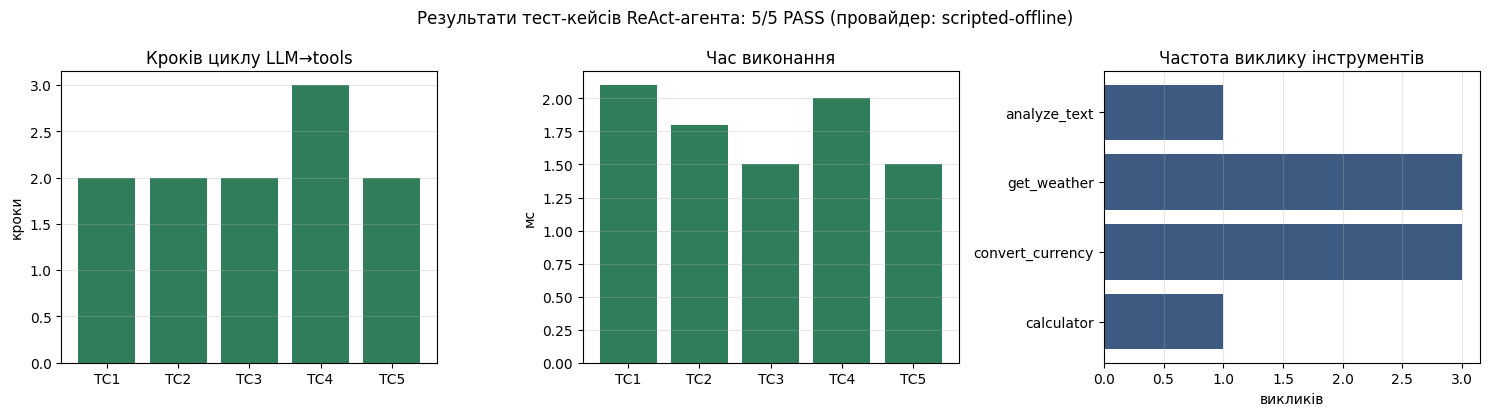

Розподіл інструментів: {'calculator': 1, 'convert_currency': 3, 'get_weather': 3, 'analyze_text': 1}


In [11]:
import matplotlib.pyplot as plt

ids = [r["id"] for r in test_results]
steps = [r["steps"] for r in test_results]
scale, unit = (1000, "мс") if max(r["duration_s"] for r in test_results) < 1 else (1, "с")
durations = [r["duration_s"] * scale for r in test_results]
colors = ["#2f7d5b" if r["passed"] else "#b03030" for r in test_results]
tool_usage = Counter(c["tool"] for r in test_results for c in r["tool_calls"])

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))

axes[0].bar(ids, steps, color=colors)
axes[0].set_title("Кроків циклу LLM→tools")
axes[0].set_ylabel("кроки")

axes[1].bar(ids, durations, color=colors)
axes[1].set_title("Час виконання")
axes[1].set_ylabel(unit)

axes[2].barh(list(tool_usage), list(tool_usage.values()), color="#3d5a80")
axes[2].set_title("Частота виклику інструментів")
axes[2].set_xlabel("викликів")

for ax in axes[:2]:
    ax.grid(axis="y", alpha=0.3)
axes[2].grid(axis="x", alpha=0.3)
fig.suptitle(f"Результати тест-кейсів ReAct-агента: {summary['passed']}/{summary['total']} PASS "
             f"(провайдер: {summary['provider']})")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "test_results.png", dpi=120)
plt.show()

print(f"Розподіл інструментів: {dict(tool_usage)}")

## Секція 8. Висновки та аналіз

### Що реалізовано
| Вимога | Реалізація |
|---|---|
| 3–4 інструменти з Pydantic v2 | `calculator`, `convert_currency`, `get_weather`, `analyze_text` — кожен з `BaseModel`, `Field(description=...)`, `field_validator` та docstring для LLM |
| LangGraph з циклом LLM–tools–LLM | `StateGraph` з вузлами `agent`/`tools`/`finalize` і двома conditional edges: `agent → tools\|finalize`, `tools → agent\|finalize` |
| Structured outputs | `with_structured_output(FinalAnswer)` у вузлі `finalize`; відповідь завжди має поля `answer`, `tools_used`, `confidence` |
| LLM-провайдер | OpenAI `gpt-4.1` через `ChatOpenAI`; детермінований офлайн-фолбек `ScriptedToolCallingLLM` для відтворюваності |
| max_steps | лічильник `step` у стані, перевірка на вході у вузол `agent` |
| timeout | `started_at` у стані, перевірка `elapsed > timeout_s` між кроками |
| детекція зациклення | підпис `name(args)` у `seen_calls`; повторний виклик → зупинка |
| логування траєкторії | `trajectory.json`: усі запуски з подіями `thought` / `observation` / `guardrail` / `final_answer` та часом кожної події |
| тест-кейси | `test_results.json`: 5 кейсів з очікуваним і фактичним результатом, кроками, tool calls, часом |

### Аналіз результатів
* **Цикл працює як ReAct.** У простому кейсі (TC1) агент робить один хід «міркування → дія → спостереження»
  і завершується structured output. У TC2 модель викликає два незалежних інструменти **в одному ході** —
  це економить ітерацію порівняно з послідовними викликами.
* **Валідація — частина міркування агента.** У TC4 перший виклик падає на `field_validator`
  (`amount <= 0`, невідома валюта `XYZ`), помилка повертається в діалог як `Observation`, і на
  наступному кроці агент виправляє аргументи. Тобто валідація не ламає цикл, а дає моделі
  зрозумілий зворотний зв'язок — це головна причина писати `raise ValueError` з людським текстом.
* **Guardrails спрацьовують раніше за `recursion_limit` LangGraph.** `max_steps` обриває план на 8 кроків
  на третій ітерації, тайм-аут — за пройденим часом між кроками, детекція повторів — на другому
  ідентичному виклику. У всіх трьох випадках агент не падає з винятком, а коректно доходить до
  `finalize` і повертає `FinalAnswer` з `confidence = 0.0` та причиною зупинки.
* **Вартість кроку.** Найдорожчий ресурс — саме LLM-виклики, а не інструменти: на офлайн-провайдері
  уся сюїта виконується за мілісекунди, тому реальний час роботи агента визначається кількістю
  ітерацій. Звідси практичний висновок: скорочення кроків (паралельні tool calls, точні описи
  інструментів) впливає на латентність і ціну сильніше за оптимізацію самих інструментів.

### Обмеження й наступні кроки
* Тайм-аут перевіряється **між кроками**, тому один аномально довгий tool call його не перерве —
  для продакшену потрібен тайм-аут на рівні окремого виклику інструмента.
* Детекція зациклення точна (повний збіг аргументів) — семантично схожі виклики
  (`Київ` / `київ ` уже нормалізуються валідатором, але `2+2` і `2 + 2` — ні) вона не зловить.
* Немає персистентності: додавання `checkpointer` дало б продовження діалогу та human-in-the-loop.

### Артефакти
* `trajectory.json` — повні траєкторії всіх запусків (демо + guardrails + тести);
* `test_results.json` — зведення та 5 тест-кейсів;
* `test_results.png` — графіки кроків, часу та частоти інструментів.